In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque

In [54]:
# 1. LOAD DATA

outdir = Path("project3_outputs")

# load numpy versions
mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

# optional: load names from covariance csv for plotting
Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)

# load feasible portfolio weights
weights_df = pd.read_csv("feasible_weights.csv")
print("\nColumns in feasible_weights.csv:", weights_df.columns.tolist())

action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

print("Number of feasible actions:", len(action_grid))
print(weights_df.head())

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]

Columns in feasible_weights.csv: ['w1', 'w2', 'w3']
Number of feasible actions: 231
    w1    w2    w3
0  0.0  0.00  1.00
1  0.0  0.05  0.95
2  0.0  0.10  0.90
3  0.0  0.15  0.85
4  0.0  0.20  0.80


In [55]:
# 2. REWARD FUNCTION
REWARD_DEFINITION = r"""
Reward definition used in this project:

For portfolio weights w_t and next-period simulated asset return vector r_{t+1},

the portfolio return is
    r_{p,t+1} = w_t' r_{t+1}

and the one-period reward is
    R_{t+1} = r_{p,t+1} - (gamma / 2) * r_{p,t+1}^2.

Interpretation:
- the first term rewards higher realized portfolio return;
- the second term penalizes large realized portfolio outcomes in a
  mean-variance-consistent way controlled by gamma >= 0.
"""


def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def mean_variance_reward(weights, asset_returns, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")

    rp = portfolio_return(weights, asset_returns)
    reward = rp - 0.5 * gamma * (rp ** 2)
    return float(reward)


def reward_components(weights, asset_returns, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")

    rp = portfolio_return(weights, asset_returns)
    return_term = float(rp)
    risk_penalty = float(0.5 * gamma * (rp ** 2))
    total_reward = float(return_term - risk_penalty)

    return {
        "portfolio_return": float(rp),
        "reward_return_term": return_term,
        "reward_risk_penalty": risk_penalty,
        "total_reward": total_reward,
    }

In [56]:
# 3. ENVIRONMENT
def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)

In [57]:
# 4. EPSILON-GREEDY POLICY
def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))

In [84]:
# 5. Q-LEARNING TRAINING LOOP
def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,
        q_tol=1e-10,
        seed=42,
        verbose=True
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Main convergence rule:
        best action unchanged for the last `convergence_window` iterations
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []

    best_action_window = deque(maxlen=convergence_window)
    small_q_change_window = deque(maxlen=convergence_window)

    converged = False
    convergence_iter = None

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        # choose action
        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        # sample next return
        r_next = sample_one_return(mu, Sigma, rng)

        # reward
        reward = mean_variance_reward(w, r_next, gamma)

        # Q update
        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        # logs
        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)

        best_action_window.append(current_best_idx)
        small_q_change_window.append(q_change < q_tol)

        # convergence check
        if t >= convergence_window:
            best_action_stable = (len(set(best_action_window)) == 1)
            q_changes_small = all(small_q_change_window)

            if best_action_stable:
                converged = True
                convergence_iter = t

                if verbose:
                    print(f"Converged at iteration {t}")
                    print(f"Best action index: {current_best_idx}")
                    print(f"Best weights: {action_grid[current_best_idx]}")
                    print(f"Q-change small condition also satisfied? {q_changes_small}")
                break

    if not converged:
        convergence_iter = max_iter
        if verbose:
            print("Did not meet convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "seed": seed,
        },
    }

In [59]:
# 6. FIXED-POLICY EVALUATION
def evaluate_fixed_policy(weights, mu, Sigma, gamma=3.0, T=5000, seed=123):
    rng = np.random.default_rng(seed)
    weights = np.asarray(weights, dtype=float)

    returns = []
    rewards = []

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(weights, r_next)
        rew = mean_variance_reward(weights, r_next, gamma)

        returns.append(rp)
        rewards.append(rew)

    returns = np.array(returns)
    rewards = np.array(rewards)

    return {
        "weights": weights,
        "mean_portfolio_return": float(np.mean(returns)),
        "var_portfolio_return": float(np.var(returns, ddof=1)),
        "std_portfolio_return": float(np.std(returns, ddof=1)),
        "mean_reward": float(np.mean(rewards)),
        "returns": returns,
        "rewards": rewards,
    }

In [60]:
# 7. GRID BENCHMARK
def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }

In [61]:
# 8. PLOTS
def plot_training_results(train_result, rolling_window=200):
    reward_history = train_result["reward_history"]
    epsilon_history = train_result["epsilon_history"]
    best_action_history = train_result["best_action_history"]
    q_max_history = train_result["q_max_history"]

    if len(reward_history) >= rolling_window:
        rolling_reward = np.convolve(
            reward_history,
            np.ones(rolling_window) / rolling_window,
            mode="valid"
        )
    else:
        rolling_reward = reward_history

    plt.figure(figsize=(8, 4))
    plt.plot(rolling_reward)
    plt.title("Rolling Average Reward")
    plt.xlabel("Iteration")
    plt.ylabel("Reward")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epsilon_history)
    plt.title("Epsilon Decay")
    plt.xlabel("Iteration")
    plt.ylabel("Epsilon")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(best_action_history)
    plt.title("Best Action Index Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Best Action Index")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(q_max_history)
    plt.title("Max Q-value Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Max Q")
    plt.tight_layout()
    plt.show()


def plot_weight_comparison(learned_weights, benchmark_weights, asset_names):
    x = np.arange(len(learned_weights))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, benchmark_weights, width=width, label="Grid Benchmark")
    plt.bar(x + width / 2, learned_weights, width=width, label="Learned Weights")

    plt.xticks(x, asset_names)
    plt.ylabel("Weight")
    plt.title("Learned Weights vs Grid Benchmark")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [63]:
gamma = 5

In [ ]:
# ===================================================
# HYPERPARAMETER TUNING 
# ===================================================

import numpy as np
import pandas as pd
from itertools import product

# ---------------------------------------------------
# 1) Benchmark on the discrete action grid
# ---------------------------------------------------
grid_bench = best_grid_benchmark(action_grid, mu_hat, Sigma_hat, gamma)
benchmark_weights = grid_bench["best_weights"]

print("Grid benchmark weights:", benchmark_weights)

# ---------------------------------------------------
# 2) Greedy evaluation on SAME return path as benchmark
# ---------------------------------------------------
def evaluate_greedy_policy_same_path(Q, action_grid, benchmark_weights,
                                     mu, Sigma, gamma, n_eval=50000, seed=123):
    """
    Evaluate the learned greedy policy against the grid benchmark
    on the SAME simulated return path.
    """
    rng = np.random.default_rng(seed)

    greedy_idx = int(np.argmax(Q))
    greedy_w = action_grid[greedy_idx]

    ql_rewards = np.empty(n_eval)
    bench_rewards = np.empty(n_eval)

    for t in range(n_eval):
        r_next = sample_one_return(mu, Sigma, rng)

        ql_rewards[t] = mean_variance_reward(greedy_w, r_next, gamma)
        bench_rewards[t] = mean_variance_reward(benchmark_weights, r_next, gamma)

    reward_gap = ql_rewards - bench_rewards

    out = {
        "greedy_idx": greedy_idx,
        "greedy_weights": greedy_w,
        "mean_greedy_reward": float(np.mean(ql_rewards)),
        "mean_benchmark_reward": float(np.mean(bench_rewards)),
        "mean_reward_gap": float(np.mean(reward_gap)),
        "cumulative_reward_gap": float(np.sum(reward_gap)),
        "distance_to_benchmark": float(np.linalg.norm(greedy_w - benchmark_weights)),
    }
    return out

# ---------------------------------------------------
# 3) Optional: evaluate average post-convergence weights too
# ---------------------------------------------------
def evaluate_average_steady_state_weights(result, action_grid, benchmark_weights,
                                          mu, Sigma, gamma, n_eval=50000, seed=456):
    """
    Uses average learned weights from the post-convergence / late-training window.
    This aligns well with the project's 'average learned weights' requirement.
    """
    action_hist = np.asarray(result["action_history"], dtype=int)
    weight_path = action_grid[action_hist]

    T = len(weight_path)
    conv_iter = result["convergence_iter"]

    if result["converged"] and conv_iter < T:
        steady_start = conv_iter
    else:
        steady_start = int(0.8 * T)

    avg_w = weight_path[steady_start:].mean(axis=0)

    rng = np.random.default_rng(seed)
    ql_rewards = np.empty(n_eval)
    bench_rewards = np.empty(n_eval)

    for t in range(n_eval):
        r_next = sample_one_return(mu, Sigma, rng)
        ql_rewards[t] = mean_variance_reward(avg_w, r_next, gamma)
        bench_rewards[t] = mean_variance_reward(benchmark_weights, r_next, gamma)

    reward_gap = ql_rewards - bench_rewards

    out = {
        "avg_weights": avg_w,
        "steady_start": steady_start,
        "mean_avg_weight_reward": float(np.mean(ql_rewards)),
        "mean_benchmark_reward_avg_eval": float(np.mean(bench_rewards)),
        "mean_reward_gap_avg_weights": float(np.mean(reward_gap)),
        "distance_avg_weights_to_benchmark": float(np.linalg.norm(avg_w - benchmark_weights)),
    }
    return out

# ---------------------------------------------------
# 4) Tuning objective
# ---------------------------------------------------
def tuning_score(greedy_eval, avg_eval=None,
                 gap_weight=1.0, dist_weight=0.25, avg_gap_weight=0.5, avg_dist_weight=0.10):
    """
    Higher is better.
    Main target: greedy policy reward gap vs benchmark.
    Penalize weight distance to benchmark.
    Also give some credit to average steady-state weights.
    """
    score = (
        gap_weight * greedy_eval["mean_reward_gap"]
        - dist_weight * greedy_eval["distance_to_benchmark"]
    )

    if avg_eval is not None:
        score += (
            avg_gap_weight * avg_eval["mean_reward_gap_avg_weights"]
            - avg_dist_weight * avg_eval["distance_avg_weights_to_benchmark"]
        )

    return float(score)

# ---------------------------------------------------
# 5) Parameter grid
# ---------------------------------------------------
# Start with a modest grid. You can expand later if needed.
param_grid = {
    "alpha": [0.0025, 0.005, 0.01, 0.02],
    "beta": [0.00002, 0.00005, 0.0001, 0.0002],
    "discount": [0.0, 0.1],
    "max_iter": [50000, 100000],
    "convergence_window": [5000, 10000],
}

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
param_combos = [dict(zip(param_names, vals)) for vals in product(*param_values)]

print(f"Trying {len(param_combos)} parameter combinations...")

# ---------------------------------------------------
# 6) Tune
# ---------------------------------------------------
tuning_rows = []

for i, params in enumerate(param_combos, start=1):
    print(f"\n[{i}/{len(param_combos)}] Testing {params}")

    result_i = train_q_learning(
        mu=mu_hat,
        Sigma=Sigma_hat,
        action_grid=action_grid,
        gamma=gamma,
        alpha=params["alpha"],
        beta=params["beta"],
        discount=params["discount"],
        max_iter=params["max_iter"],
        convergence_window=params["convergence_window"],
        q_tol=1e-8,
        seed=42,
        verbose=False
    )

    greedy_eval = evaluate_greedy_policy_same_path(
        Q=result_i["Q"],
        action_grid=action_grid,
        benchmark_weights=benchmark_weights,
        mu=mu_hat,
        Sigma=Sigma_hat,
        gamma=gamma,
        n_eval=20000,   # raise to 50000 later if you want
        seed=123
    )

    avg_eval = evaluate_average_steady_state_weights(
        result=result_i,
        action_grid=action_grid,
        benchmark_weights=benchmark_weights,
        mu=mu_hat,
        Sigma=Sigma_hat,
        gamma=gamma,
        n_eval=20000,
        seed=456
    )

    score = tuning_score(greedy_eval, avg_eval)

    row = {
        **params,
        "score": score,
        "converged": result_i["converged"],
        "convergence_iter": result_i["convergence_iter"],
        "best_action_idx": int(np.argmax(result_i["Q"])),
        "greedy_mean_reward": greedy_eval["mean_greedy_reward"],
        "benchmark_mean_reward": greedy_eval["mean_benchmark_reward"],
        "greedy_mean_reward_gap": greedy_eval["mean_reward_gap"],
        "greedy_cumulative_reward_gap": greedy_eval["cumulative_reward_gap"],
        "greedy_distance_to_benchmark": greedy_eval["distance_to_benchmark"],
        "avg_weight_mean_reward": avg_eval["mean_avg_weight_reward"],
        "avg_weight_mean_reward_gap": avg_eval["mean_reward_gap_avg_weights"],
        "avg_weight_distance_to_benchmark": avg_eval["distance_avg_weights_to_benchmark"],
        "greedy_weights": greedy_eval["greedy_weights"],
        "avg_weights": avg_eval["avg_weights"],
    }

    tuning_rows.append(row)

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=["score", "greedy_mean_reward_gap"],
    ascending=False
).reset_index(drop=True)

print("\n===== TOP TUNING RESULTS =====")
display(
    tuning_results[
        [
            "alpha", "beta", "discount", "max_iter", "convergence_window",
            "score", "converged", "convergence_iter",
            "greedy_mean_reward_gap", "greedy_distance_to_benchmark",
            "avg_weight_mean_reward_gap", "avg_weight_distance_to_benchmark"
        ]
    ].head(15)
)

best_params = tuning_results.loc[0, ["alpha", "beta", "discount", "max_iter", "convergence_window"]].to_dict()

print("\nBest params found:")
print(best_params)

print("\nBest greedy weights:")
print(tuning_results.loc[0, "greedy_weights"])

print("\nBest average steady-state weights:")
print(tuning_results.loc[0, "avg_weights"])

Grid benchmark weights: [0.65 0.   0.35]
Trying 128 parameter combinations...

[1/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.0, 'max_iter': 50000, 'convergence_window': 5000}

[2/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.0, 'max_iter': 50000, 'convergence_window': 10000}

[3/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.0, 'max_iter': 100000, 'convergence_window': 5000}

[4/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.0, 'max_iter': 100000, 'convergence_window': 10000}

[5/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 50000, 'convergence_window': 5000}

[6/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 50000, 'convergence_window': 10000}

[7/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 100000, 'convergence_window': 5000}

[8/128] Testing {'alpha': 0.0025, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 100000, 'convergence_window': 10000}

[

,alpha,beta,discount,max_iter,convergence_window,score,converged,convergence_iter,greedy_mean_reward_gap,greedy_distance_to_benchmark,avg_weight_mean_reward_gap,avg_weight_distance_to_benchmark
0,0.010,0.00002,0.1,50000,5000,-0.036225,False,50000,0.000000,0.000000,-0.000102,0.361744
1,0.010,0.00002,0.1,50000,10000,-0.036225,False,50000,0.000000,0.000000,-0.000102,0.361744
2,0.005,0.00005,0.0,100000,5000,-0.065351,False,100000,-0.000041,0.122474,-0.000091,0.346457
3,0.005,0.00005,0.0,100000,10000,-0.065351,False,100000,-0.000041,0.122474,-0.000091,0.346457
4,0.005,0.00020,0.0,50000,5000,-0.070230,False,50000,-0.000020,0.122474,-0.000116,0.395328
5,0.005,0.00020,0.0,50000,10000,-0.070230,False,50000,-0.000020,0.122474,-0.000116,0.395328
6,0.010,0.00002,0.1,100000,5000,-0.072980,False,100000,-0.000024,0.122474,-0.000113,0.422799
7,0.010,0.00002,0.1,100000,10000,-0.072980,False,100000,-0.000024,0.122474,-0.000113,0.422799
8,0.010,0.00020,0.0,100000,5000,-0.090205,False,100000,-0.000006,0.141421,-0.000164,0.547615
9,0.010,0.00020,0.0,100000,10000,-0.090205,False,100000,-0.000006,0.141421,-0.000164,0.547615



Best params found:
{'alpha': 0.01, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 50000, 'convergence_window': 5000}

Best greedy weights:
[0.65 0.   0.35]

Best average steady-state weights:
[0.420215 0.275605 0.30418 ]


In [85]:
# ===================================================
# FINAL TRAINING RUN USING BEST PARAMS
# ===================================================

result = train_q_learning(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha=float(best_params["alpha"]),
    beta=float(best_params["beta"]),
    discount=float(best_params["discount"]),
    max_iter=int(best_params["max_iter"]),
    convergence_window=int(best_params["convergence_window"]),
    q_tol=1e-8,
    seed=42,
    verbose=True
)

print("\nFinal chosen greedy action index:", int(np.argmax(result["Q"])))
print("Final greedy weights:", action_grid[int(np.argmax(result["Q"]))])

final_greedy_eval = evaluate_greedy_policy_same_path(
    Q=result["Q"],
    action_grid=action_grid,
    benchmark_weights=benchmark_weights,
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    n_eval=10000,
    seed=999
)

print("\n===== FINAL GREEDY EVALUATION =====")
for k, v in final_greedy_eval.items():
    print(f"{k}: {v}")

Did not meet convergence rule before max_iter.
Using final iteration = 50000

Final chosen greedy action index: 195
Final greedy weights: [0.65 0.   0.35]

===== FINAL GREEDY EVALUATION =====
greedy_idx: 195
greedy_weights: [0.65 0.   0.35]
mean_greedy_reward: 0.00032278815665640737
mean_benchmark_reward: 0.00032278815665640737
mean_reward_gap: 0.0
cumulative_reward_gap: 0.0
distance_to_benchmark: 0.0


In [86]:
# 10. EVALUATE LEARNED POLICY
eval_result = evaluate_fixed_policy(
    weights=result["best_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=5000,
    seed=123
)

print("\n===== Learned Policy Evaluation =====")
print("Mean portfolio return:", eval_result["mean_portfolio_return"])
print("Variance of portfolio return:", eval_result["var_portfolio_return"])
print("Std portfolio return:", eval_result["std_portfolio_return"])
print("Mean reward:", eval_result["mean_reward"])


===== Learned Policy Evaluation =====
Mean portfolio return: 0.00020972436495406645
Variance of portfolio return: 6.186520278912217e-05
Std portfolio return: 0.007865443585019357
Mean reward: 5.498232980951727e-05


In [87]:
# 11. COMPARE WITH GRID BENCHMARK
grid_bench = best_grid_benchmark(action_grid, mu_hat, Sigma_hat, gamma)
benchmark_weights = grid_bench["best_weights"]

learned_stats = utility_from_moments(result["best_weights"], mu_hat, Sigma_hat, gamma)
benchmark_stats = utility_from_moments(benchmark_weights, mu_hat, Sigma_hat, gamma)

distance_to_grid_benchmark = np.linalg.norm(result["best_weights"] - benchmark_weights)

print("\n===== Grid Benchmark =====")
print("Benchmark action index:", grid_bench["best_idx"])
print("Benchmark weights:", benchmark_weights)
print("Benchmark theoretical stats:", benchmark_stats)

print("\n===== Learned Weights Theoretical Stats =====")
print(learned_stats)

print("\nDistance to grid benchmark:", distance_to_grid_benchmark)


===== Grid Benchmark =====
Benchmark action index: 195
Benchmark weights: [0.65 0.   0.35]
Benchmark theoretical stats: {'mean': 0.0004483869093461014, 'variance': 6.285589697208574e-05, 'utility': 0.00029124716691588705}

===== Learned Weights Theoretical Stats =====
{'mean': 0.0004483869093461014, 'variance': 6.285589697208574e-05, 'utility': 0.00029124716691588705}

Distance to grid benchmark: 0.0


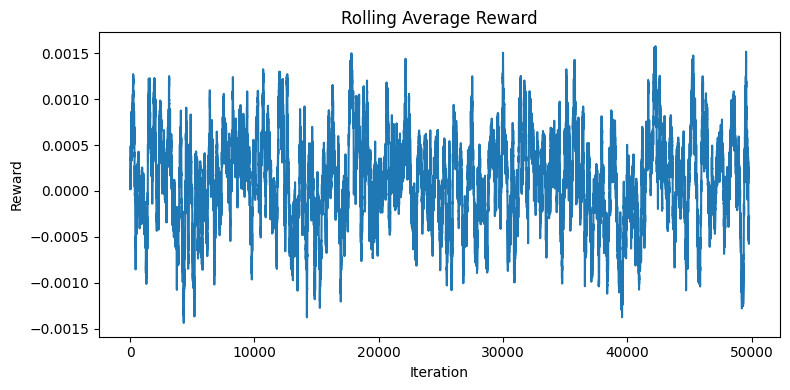

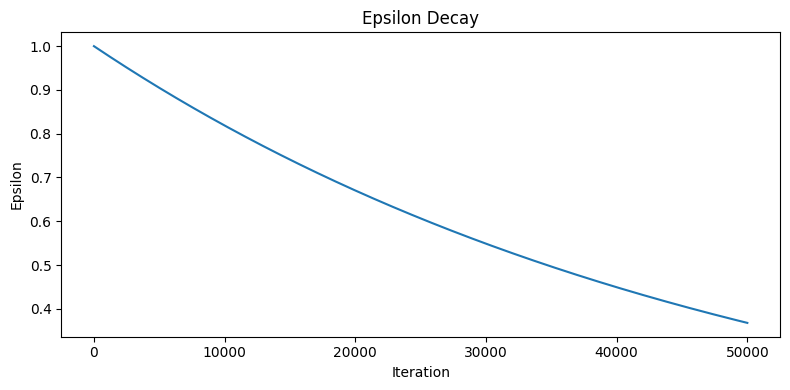

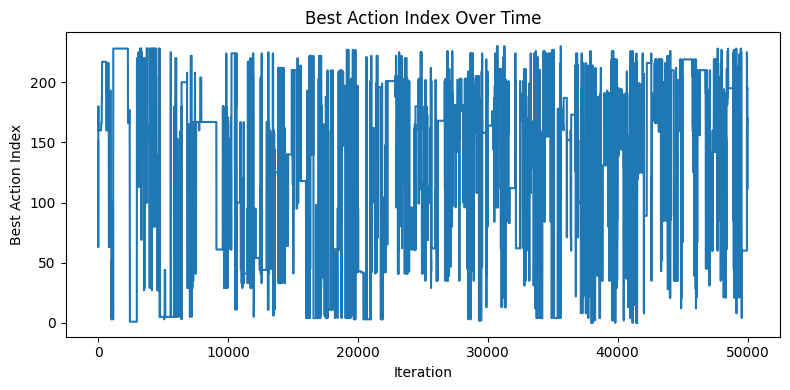

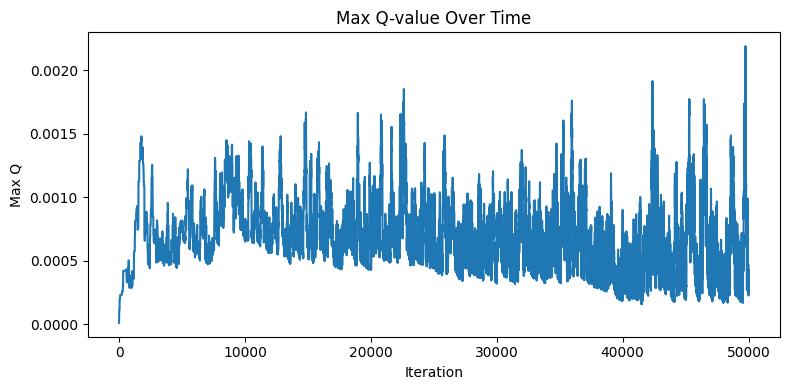

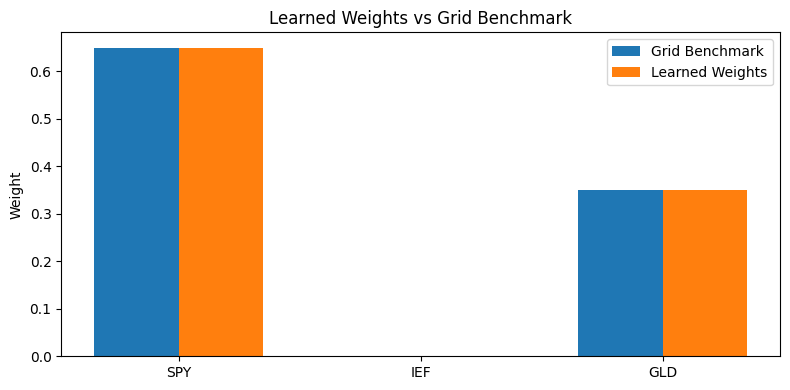

In [88]:
# 12. PLOTS
plot_training_results(result, rolling_window=200)
plot_weight_comparison(
    learned_weights=result["best_weights"],
    benchmark_weights=benchmark_weights,
    asset_names=asset_names
)


===== PROJECT EVALUATION: WEIGHT COMPARISON =====
  asset  benchmark_weight  avg_learned_weight  final_learned_weight  \
0   SPY              0.65            0.420215                  0.65   
1   IEF              0.00            0.275605                  0.00   
2   GLD              0.35            0.304180                  0.35   

   avg_minus_benchmark  final_minus_benchmark  
0            -0.229785                    0.0  
1             0.275605                    0.0  
2            -0.045820                    0.0  

===== PROJECT EVALUATION: PERFORMANCE SUMMARY =====
                             metric     value
0               training_iterations     50000
1                    converged_flag     False
2             convergence_iteration     50000
3                steady_state_start     40000
4              mean_training_reward  0.000112
5             mean_benchmark_reward  0.000291
6                   mean_reward_gap  -0.00018
7       final_cumulative_reward_gap -8.983535
8    

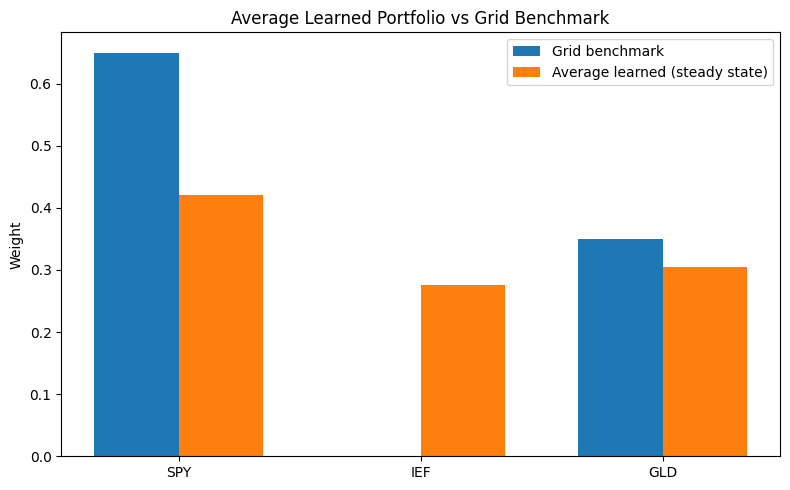

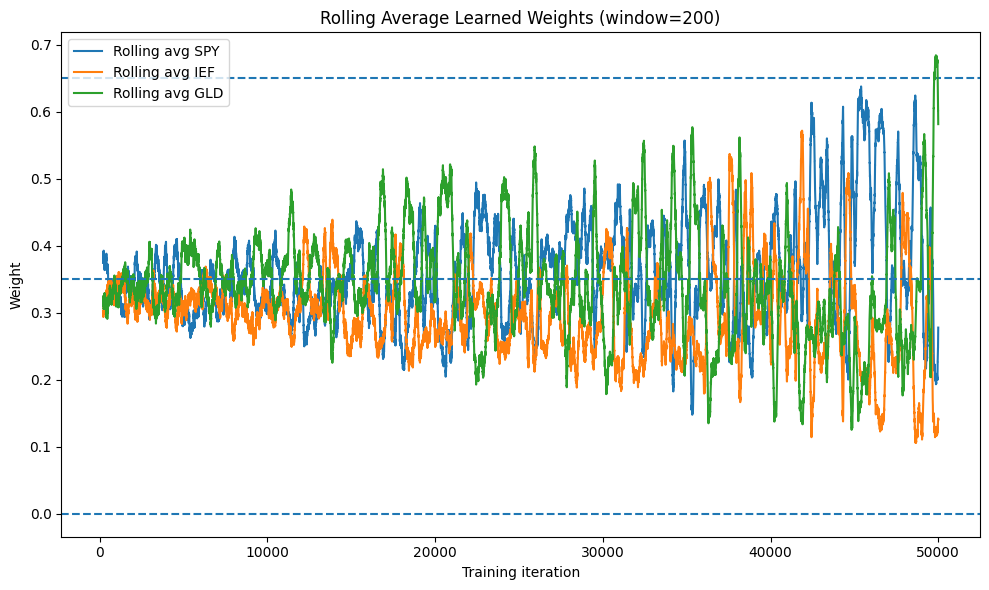

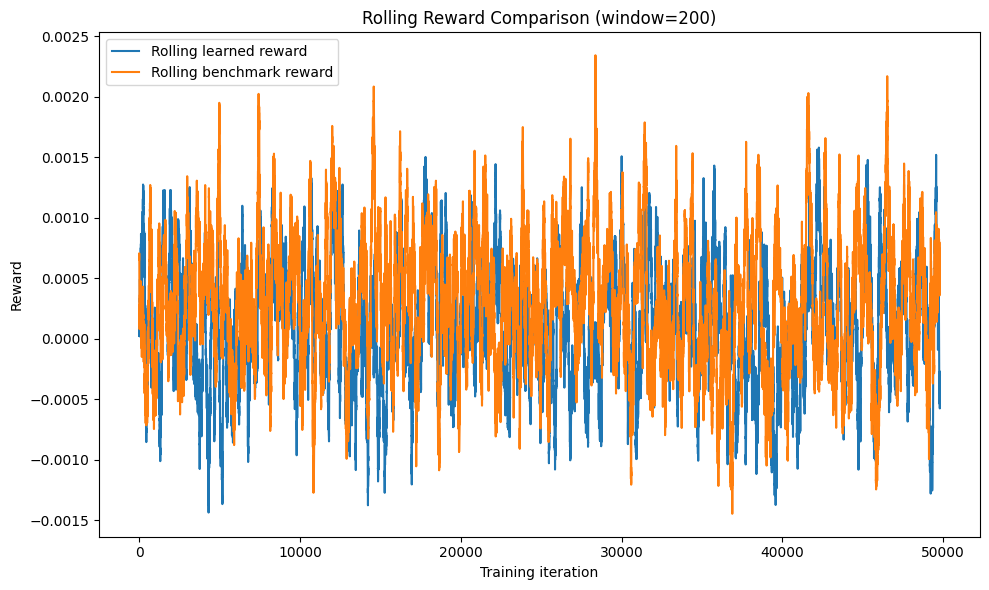

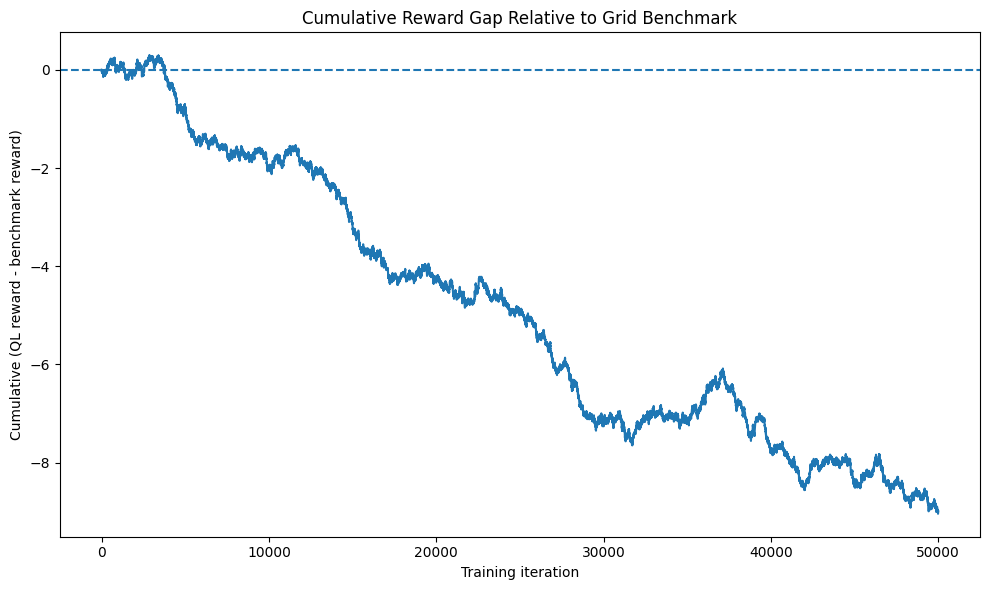

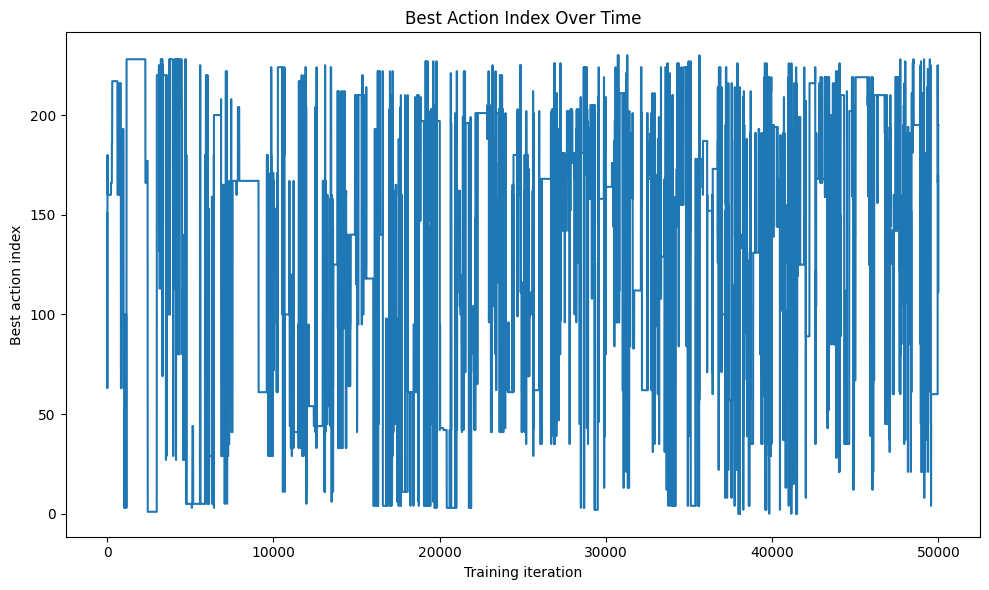

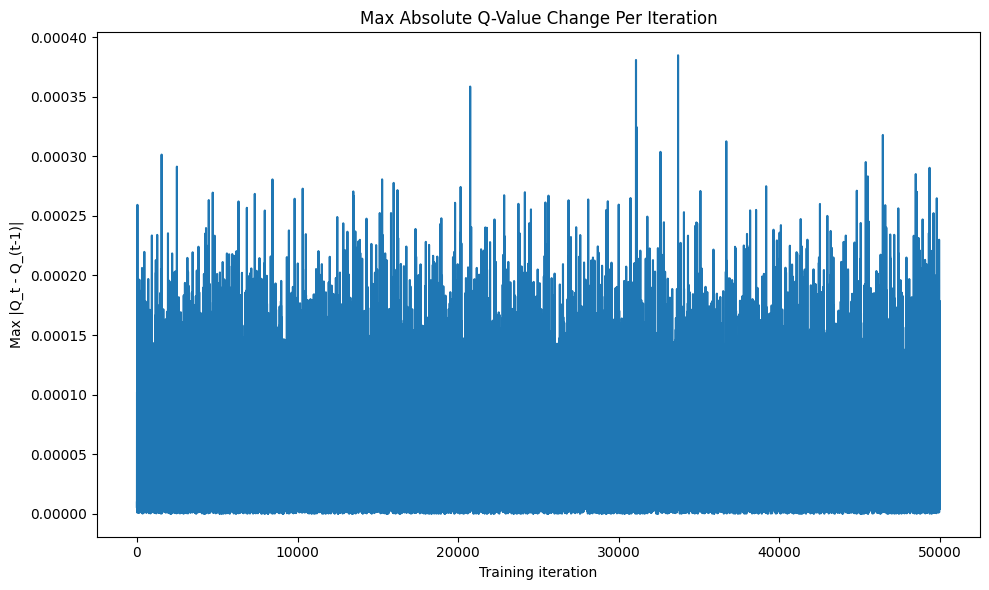

In [89]:
# 12. PROJECT EVALUATION: CONVERGENCE + COMPARISON

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Use the existing objects from this notebook:
# - result
# - action_grid
# - mu_hat
# - Sigma_hat
# - gamma
# - asset_names
# - benchmark_weights (from cell 11)
# ---------------------------------------------------

# Recover the portfolio chosen at each training step
chosen_action_idx_history = result["action_history"]
learned_weight_path = action_grid[chosen_action_idx_history]   # shape: (T, 3)
reward_history = result["reward_history"]
convergence_iter = result["convergence_iter"]

# ---------------------------------------------------
# Define steady-state window
# ---------------------------------------------------
# If the algorithm converged, use post-convergence observations.
# If not, use the last 20% of training as a fallback.
T_train = len(chosen_action_idx_history)

if result["converged"] and convergence_iter < T_train:
    steady_start = convergence_iter
else:
    steady_start = int(0.8 * T_train)

steady_weights = learned_weight_path[steady_start:]
w_bar_QL = steady_weights.mean(axis=0)

# ---------------------------------------------------
# Distance from average learned weights to benchmark
# ---------------------------------------------------
# Use the grid benchmark from cell 11 because Q-learning chooses
# from the discrete action grid.
distance_avg_to_grid_benchmark = np.linalg.norm(w_bar_QL - benchmark_weights)

# Also compare final greedy learned action to the benchmark
distance_final_to_grid_benchmark = np.linalg.norm(result["best_weights"] - benchmark_weights)

# ---------------------------------------------------
# Simulate benchmark reward path on the SAME number of periods
# ---------------------------------------------------
# This gives a fair same-horizon comparison in expectation.
rng_eval = np.random.default_rng(999)

benchmark_reward_history = []
benchmark_return_history = []

for _ in range(T_train):
    r_next = sample_one_return(mu_hat, Sigma_hat, rng_eval)
    rp_bench = portfolio_return(benchmark_weights, r_next)
    rew_bench = mean_variance_reward(benchmark_weights, r_next, gamma)

    benchmark_return_history.append(rp_bench)
    benchmark_reward_history.append(rew_bench)

benchmark_reward_history = np.array(benchmark_reward_history)
benchmark_return_history = np.array(benchmark_return_history)

reward_gap = reward_history - benchmark_reward_history
cumulative_reward_gap = np.cumsum(reward_gap)

# ---------------------------------------------------
# Rolling diagnostics
# ---------------------------------------------------
def rolling_mean_1d(x, window):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    return np.convolve(x, np.ones(window) / window, mode="valid")

def rolling_mean_2d(x, window):
    x = np.asarray(x, dtype=float)
    out = np.full((len(x), x.shape[1]), np.nan)
    if len(x) < window:
        out[:] = x
        return out
    for t in range(window - 1, len(x)):
        out[t] = x[t - window + 1:t + 1].mean(axis=0)
    return out

rolling_window = 200
rolling_reward = rolling_mean_1d(reward_history, rolling_window)
rolling_benchmark_reward = rolling_mean_1d(benchmark_reward_history, rolling_window)
rolling_weights = rolling_mean_2d(learned_weight_path, rolling_window)

# ---------------------------------------------------
# Weight comparison summary
# ---------------------------------------------------
weight_comparison = pd.DataFrame({
    "asset": asset_names,
    "benchmark_weight": benchmark_weights,
    "avg_learned_weight": w_bar_QL,
    "final_learned_weight": result["best_weights"],
    "avg_minus_benchmark": w_bar_QL - benchmark_weights,
    "final_minus_benchmark": result["best_weights"] - benchmark_weights,
})

print("\n===== PROJECT EVALUATION: WEIGHT COMPARISON =====")
print(weight_comparison.round(6))

# ---------------------------------------------------
# Performance summary
# ---------------------------------------------------
performance_summary = pd.DataFrame({
    "metric": [
        "training_iterations",
        "converged_flag",
        "convergence_iteration",
        "steady_state_start",
        "mean_training_reward",
        "mean_benchmark_reward",
        "mean_reward_gap",
        "final_cumulative_reward_gap",
        "distance_avg_to_grid_benchmark",
        "distance_final_to_grid_benchmark",
    ],
    "value": [
        T_train,
        result["converged"],
        convergence_iter,
        steady_start,
        float(np.mean(reward_history)),
        float(np.mean(benchmark_reward_history)),
        float(np.mean(reward_gap)),
        float(cumulative_reward_gap[-1]),
        float(distance_avg_to_grid_benchmark),
        float(distance_final_to_grid_benchmark),
    ]
})

print("\n===== PROJECT EVALUATION: PERFORMANCE SUMMARY =====")
print(performance_summary)

# ---------------------------------------------------
# PLOT 1: Average learned weights vs benchmark
# ---------------------------------------------------
x = np.arange(len(asset_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, benchmark_weights, width=width, label="Grid benchmark")
plt.bar(x + width/2, w_bar_QL, width=width, label="Average learned (steady state)")
plt.xticks(x, asset_names)
plt.ylabel("Weight")
plt.title("Average Learned Portfolio vs Grid Benchmark")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# PLOT 2: Rolling average learned weights
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
for j, asset in enumerate(asset_names):
    plt.plot(rolling_weights[:, j], label=f"Rolling avg {asset}")
    plt.axhline(benchmark_weights[j], linestyle="--")

plt.title(f"Rolling Average Learned Weights (window={rolling_window})")
plt.xlabel("Training iteration")
plt.ylabel("Weight")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# PLOT 3: Rolling average reward vs benchmark reward
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(rolling_reward, label="Rolling learned reward")
plt.plot(rolling_benchmark_reward, label="Rolling benchmark reward")
plt.title(f"Rolling Reward Comparison (window={rolling_window})")
plt.xlabel("Training iteration")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# PLOT 4: Cumulative reward gap relative to benchmark
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(cumulative_reward_gap)
plt.axhline(0, linestyle="--")
plt.title("Cumulative Reward Gap Relative to Grid Benchmark")
plt.xlabel("Training iteration")
plt.ylabel("Cumulative (QL reward - benchmark reward)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# PLOT 5: Existing convergence diagnostics from training loop
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(result["best_action_history"])
plt.title("Best Action Index Over Time")
plt.xlabel("Training iteration")
plt.ylabel("Best action index")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(result["q_change_history"])
plt.title("Max Absolute Q-Value Change Per Iteration")
plt.xlabel("Training iteration")
plt.ylabel("Max |Q_t - Q_(t-1)|")
plt.tight_layout()
plt.show()

# Extra Credit

Long-only grid size: 231
Bounded grid size  : 1161

LONG-ONLY (NO SHORTING) CASE
Number of actions: 231
Constrained benchmark weights: [0.65 0.   0.35]

Best local params:
{'alpha': 0.01, 'beta': 2e-05, 'discount': 0.1, 'max_iter': 50000.0, 'convergence_window': 5000.0}
Did not meet convergence rule before max_iter.
Using final iteration = 50000

Final greedy evaluation:
greedy_idx: 195
greedy_weights: [0.65 0.   0.35]
mean_greedy_reward: 0.00029370989281262604
mean_benchmark_reward: 0.00029370989281262604
mean_reward_gap: 0.0
cumulative_reward_gap: 0.0
distance_to_benchmark: 0.0


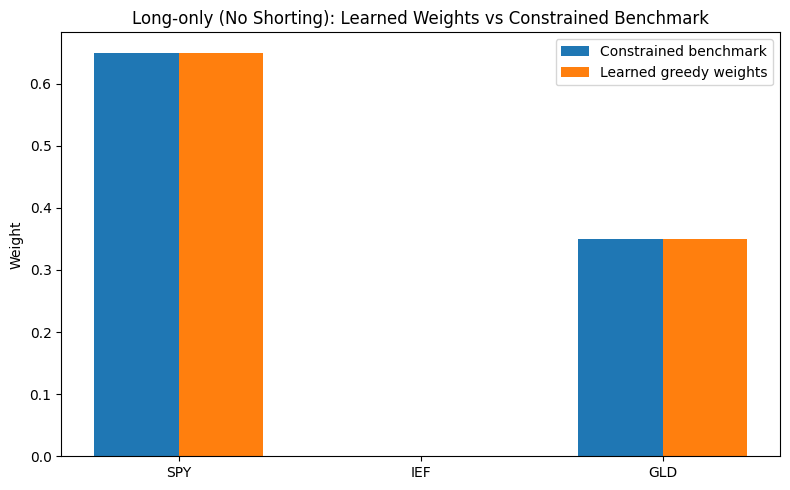


Weight comparison:
  asset  benchmark_weight  learned_weight  difference
0   SPY              0.65            0.65         0.0
1   IEF              0.00            0.00         0.0
2   GLD              0.35            0.35         0.0

BOUNDED WEIGHTS [-0.5, 1.5] CASE
Number of actions: 1161
Constrained benchmark weights: [ 0.8 -0.5  0.7]

Best local params:
{'alpha': 0.01, 'beta': 1e-05, 'discount': 0.1, 'max_iter': 50000.0, 'convergence_window': 5000.0}
Did not meet convergence rule before max_iter.
Using final iteration = 50000

Final greedy evaluation:
greedy_idx: 515
greedy_weights: [ 0.2 -0.4  1.2]
mean_greedy_reward: 0.0003041382181763751
mean_benchmark_reward: 0.00047325854455690684
mean_reward_gap: -0.0001691203263805318
cumulative_reward_gap: -8.45601631902659
distance_to_benchmark: 0.7874007874011811


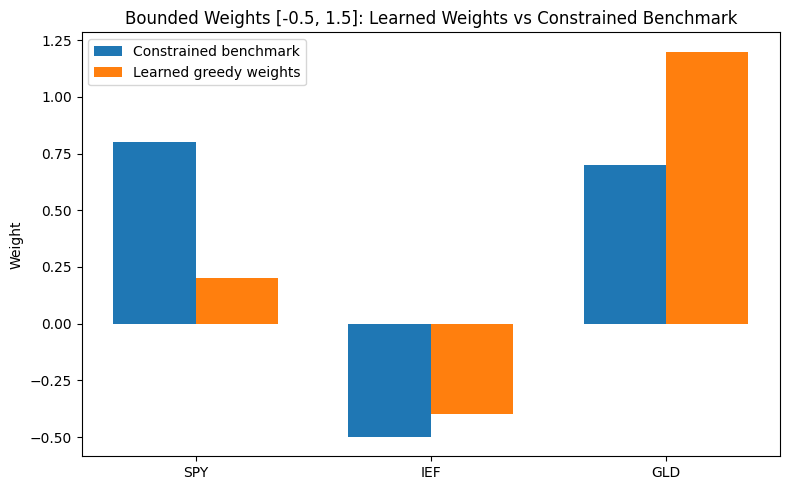


Weight comparison:
  asset  benchmark_weight  learned_weight  difference
0   SPY               0.8             0.2        -0.6
1   IEF              -0.5            -0.4         0.1
2   GLD               0.7             1.2         0.5


In [ ]:
# ===================================================
# 13. EXTRA CREDIT: NO-SHORTING AND BOUNDED-WEIGHT CASES
# ===================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Use your best-tested params as the default starting point
# Update these if your final tuned params differ
# ---------------------------------------------------
best_params_base = {
    "alpha": 0.01,
    "beta": 2e-05,
    "discount": 0.1,
    "max_iter": 50000,
    "convergence_window": 5000,
}

# Make sure gamma is defined consistently with the rest of the notebook
gamma = 5  # replace only if your project uses a different gamma


# ---------------------------------------------------
# ACTION GRID BUILDERS
# ---------------------------------------------------
def make_long_only_grid(step=0.05):
    """
    Long-only portfolio grid:
    w1 >= 0, w2 >= 0, w3 = 1-w1-w2 >= 0
    """
    vals = np.round(np.arange(0.0, 1.0 + step/2, step), 10)
    grid = []

    for w1 in vals:
        for w2 in vals:
            w3 = round(1.0 - w1 - w2, 10)
            if w3 < -1e-10:
                continue
            if w3 < 0:
                w3 = 0.0
            if np.isclose(w1 + w2 + w3, 1.0):
                grid.append([w1, w2, w3])

    grid = np.unique(np.round(np.asarray(grid, dtype=float), 10), axis=0)
    return grid


def make_bounded_grid(lower=-0.5, upper=1.5, step=0.05):
    """
    Bounded-weight portfolio grid:
    lower <= wi <= upper, sum wi = 1
    We discretize w1, w2 and back out w3.
    """
    vals = np.round(np.arange(lower, upper + step/2, step), 10)
    grid = []

    for w1 in vals:
        for w2 in vals:
            w3 = round(1.0 - w1 - w2, 10)
            if w3 < lower - 1e-10 or w3 > upper + 1e-10:
                continue
            if np.isclose(w1 + w2 + w3, 1.0):
                grid.append([w1, w2, w3])

    grid = np.unique(np.round(np.asarray(grid, dtype=float), 10), axis=0)
    return grid


# ---------------------------------------------------
# SAME-PATH GREEDY EVALUATION
# ---------------------------------------------------
def evaluate_greedy_policy_same_path(Q, action_grid, benchmark_weights,
                                     mu, Sigma, gamma, n_eval=50000, seed=123):
    rng = np.random.default_rng(seed)

    greedy_idx = int(np.argmax(Q))
    greedy_w = action_grid[greedy_idx]

    ql_rewards = np.empty(n_eval)
    bench_rewards = np.empty(n_eval)

    for t in range(n_eval):
        r_next = sample_one_return(mu, Sigma, rng)
        ql_rewards[t] = mean_variance_reward(greedy_w, r_next, gamma)
        bench_rewards[t] = mean_variance_reward(benchmark_weights, r_next, gamma)

    reward_gap = ql_rewards - bench_rewards

    return {
        "greedy_idx": greedy_idx,
        "greedy_weights": greedy_w,
        "mean_greedy_reward": float(np.mean(ql_rewards)),
        "mean_benchmark_reward": float(np.mean(bench_rewards)),
        "mean_reward_gap": float(np.mean(reward_gap)),
        "cumulative_reward_gap": float(np.sum(reward_gap)),
        "distance_to_benchmark": float(np.linalg.norm(greedy_w - benchmark_weights)),
    }


# ---------------------------------------------------
# SMALL LOCAL RETUNE AROUND BEST BASE PARAMS
# This is much cheaper than full retuning
# ---------------------------------------------------
def local_tune_for_constraint(action_grid_constraint, mu, Sigma, gamma, benchmark_weights,
                              base_params, n_eval=15000):
    candidate_params = [
        {
            "alpha": base_params["alpha"] * 0.5,
            "beta": base_params["beta"],
            "discount": base_params["discount"],
            "max_iter": base_params["max_iter"],
            "convergence_window": base_params["convergence_window"],
        },
        {
            "alpha": base_params["alpha"],
            "beta": base_params["beta"],
            "discount": base_params["discount"],
            "max_iter": base_params["max_iter"],
            "convergence_window": base_params["convergence_window"],
        },
        {
            "alpha": base_params["alpha"] * 2.0,
            "beta": base_params["beta"],
            "discount": base_params["discount"],
            "max_iter": base_params["max_iter"],
            "convergence_window": base_params["convergence_window"],
        },
        {
            "alpha": base_params["alpha"],
            "beta": max(base_params["beta"] * 0.5, 1e-6),
            "discount": base_params["discount"],
            "max_iter": base_params["max_iter"],
            "convergence_window": base_params["convergence_window"],
        },
        {
            "alpha": base_params["alpha"],
            "beta": base_params["beta"] * 2.0,
            "discount": base_params["discount"],
            "max_iter": base_params["max_iter"],
            "convergence_window": base_params["convergence_window"],
        },
    ]

    rows = []

    for params in candidate_params:
        seed_scores = []

        for seed in [11, 22]:
            result_i = train_q_learning(
                mu=mu,
                Sigma=Sigma,
                action_grid=action_grid_constraint,
                gamma=gamma,
                alpha=params["alpha"],
                beta=params["beta"],
                discount=params["discount"],
                max_iter=params["max_iter"],
                convergence_window=params["convergence_window"],
                q_tol=1e-8,
                seed=seed,
                verbose=False
            )

            eval_i = evaluate_greedy_policy_same_path(
                Q=result_i["Q"],
                action_grid=action_grid_constraint,
                benchmark_weights=benchmark_weights,
                mu=mu,
                Sigma=Sigma,
                gamma=gamma,
                n_eval=n_eval,
                seed=999
            )

            score = eval_i["mean_reward_gap"] - 0.25 * eval_i["distance_to_benchmark"]
            seed_scores.append(score)

        rows.append({
            **params,
            "score": float(np.mean(seed_scores))
        })

    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return out


# ---------------------------------------------------
# MAIN WRAPPER FOR EACH CONSTRAINT CASE
# ---------------------------------------------------
def run_constraint_case(case_name, action_grid_constraint, mu, Sigma, gamma,
                        asset_names, base_params, do_local_tune=True):
    print(f"\n{'='*70}")
    print(f"{case_name.upper()} CASE")
    print(f"{'='*70}")
    print(f"Number of actions: {len(action_grid_constraint)}")

    # Constrained benchmark
    bench = best_grid_benchmark(action_grid_constraint, mu, Sigma, gamma)
    benchmark_weights = bench["best_weights"]

    print("Constrained benchmark weights:", benchmark_weights)

    # Optional cheap local retune
    if do_local_tune:
        tune_df = local_tune_for_constraint(
            action_grid_constraint=action_grid_constraint,
            mu=mu,
            Sigma=Sigma,
            gamma=gamma,
            benchmark_weights=benchmark_weights,
            base_params=base_params,
            n_eval=10000
        )
        use_params = tune_df.loc[0, ["alpha", "beta", "discount", "max_iter", "convergence_window"]].to_dict()
        print("\nBest local params:")
        print(use_params)
    else:
        tune_df = None
        use_params = base_params.copy()

    # Final training
    result_case = train_q_learning(
        mu=mu,
        Sigma=Sigma,
        action_grid=action_grid_constraint,
        gamma=gamma,
        alpha=float(use_params["alpha"]),
        beta=float(use_params["beta"]),
        discount=float(use_params["discount"]),
        max_iter=int(use_params["max_iter"]),
        convergence_window=int(use_params["convergence_window"]),
        q_tol=1e-8,
        seed=42,
        verbose=True
    )

    final_eval = evaluate_greedy_policy_same_path(
        Q=result_case["Q"],
        action_grid=action_grid_constraint,
        benchmark_weights=benchmark_weights,
        mu=mu,
        Sigma=Sigma,
        gamma=gamma,
        n_eval=50000,
        seed=1234
    )

    print("\nFinal greedy evaluation:")
    for k, v in final_eval.items():
        print(f"{k}: {v}")

    # Plot learned greedy weights vs constrained benchmark
    learned_weights = final_eval["greedy_weights"]

    x = np.arange(len(asset_names))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, benchmark_weights, width=width, label="Constrained benchmark")
    plt.bar(x + width/2, learned_weights, width=width, label="Learned greedy weights")
    plt.xticks(x, asset_names)
    plt.ylabel("Weight")
    plt.title(f"{case_name}: Learned Weights vs Constrained Benchmark")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Summary table
    summary_df = pd.DataFrame({
        "asset": asset_names,
        "benchmark_weight": benchmark_weights,
        "learned_weight": learned_weights,
        "difference": learned_weights - benchmark_weights
    })

    print("\nWeight comparison:")
    print(summary_df.round(6))

    return {
        "case_name": case_name,
        "action_grid": action_grid_constraint,
        "benchmark_weights": benchmark_weights,
        "params_used": use_params,
        "tuning_results": tune_df,
        "result": result_case,
        "final_eval": final_eval,
        "summary_df": summary_df,
    }


# ---------------------------------------------------
# BUILD CONSTRAINED GRIDS
# ---------------------------------------------------
asset_names = ["SPY", "IEF", "GLD"]  # keep consistent with your notebook

action_grid_long_only = make_long_only_grid(step=0.05)
action_grid_bounded = make_bounded_grid(lower=-0.5, upper=1.5, step=0.05)

print("Long-only grid size:", len(action_grid_long_only))
print("Bounded grid size  :", len(action_grid_bounded))


# ---------------------------------------------------
# RUN EXTRA CREDIT CASES
# ---------------------------------------------------
long_only_out = run_constraint_case(
    case_name="Long-only (No Shorting)",
    action_grid_constraint=action_grid_long_only,
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    asset_names=asset_names,
    base_params=best_params_base,
    do_local_tune=True
)